In [2]:
# Local/WSL workflow: no Colab drive mount needed.


In [3]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import mixed_precision

gpus = tf.config.list_physical_devices("GPU")
for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)

if gpus:
    mixed_precision.set_global_policy("mixed_float16")

print("TF version:", tf.__version__)
print("GPU:", gpus)
print("Mixed precision policy:", mixed_precision.global_policy())

from tensorflow.keras import layers
from tensorflow.keras.applications import ResNet50
from tensorflow.keras import regularizers
import matplotlib.pyplot as plt
import numpy as np

TF version: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Mixed precision policy: <DTypePolicy "mixed_float16">


In [4]:
import os
import random
import keras_hub
from collections import Counter
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
)


/home/dell/miniconda3/envs/tf218/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
def count_files_by_class(root_dir):
    counts = {}
    for class_name in sorted(os.listdir(root_dir)):
        class_dir = os.path.join(root_dir, class_name)
        if not os.path.isdir(class_dir):
            continue
        counts[class_name] = sum(
            1
            for file_name in os.listdir(class_dir)
            if file_name.lower().endswith((".jpg"))
        )
    return counts


def summarize_labels(ds, class_names):
    counts = Counter()
    for _, labels in ds:
        labels = labels.numpy().astype("int32").reshape(-1)
        counts.update(labels.tolist())
    return {class_names[idx]: counts.get(idx, 0) for idx in range(len(class_names))}


In [6]:
# Dataset path is configured in the next cell.


In [7]:
data_dir = "/mnt/e/DDSM/ROI"
assert os.path.exists(data_dir), f"Dataset path not found: {data_dir}"
print("Using data_dir:", data_dir)

Using data_dir: /mnt/e/DDSM/ROI


In [8]:
raw_class_counts = count_files_by_class(data_dir)
print("Raw file counts by class:", raw_class_counts)


Raw file counts by class: {'ROI_Benign': 1402, 'ROI_Cancer': 1428}


Quick check: inspect one training batch after the dataset cell runs.

Diagnostics: verify split sizes, class balance, and one sample batch before training.

In [9]:
img_size = (224, 224)
batch_size = 16
seed = 123
AUTOTUNE = tf.data.AUTOTUNE

os.environ["PYTHONHASHSEED"] = str(seed)
random.seed(seed)
np.random.seed(seed)
tf.random.set_seed(seed)
keras.utils.set_random_seed(seed)
try:
    tf.config.experimental.enable_op_determinism()
except Exception:
    pass

train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    labels="inferred",
    label_mode="binary",
    validation_split=0.2,
    subset="training",
    seed=seed,
    image_size=img_size,
    batch_size=batch_size,
    shuffle=True,
)

temp_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    labels="inferred",
    label_mode="binary",
    validation_split=0.2,
    subset="validation",
    seed=seed,
    image_size=img_size,
    batch_size=batch_size,
    shuffle=True,
)

class_names = train_ds.class_names
print("Classes:", class_names)
print(f"Positive class for AUC/ROC: {class_names[1]}")

temp_card = tf.data.experimental.cardinality(temp_ds).numpy()
if temp_card < 2:
    raise ValueError(f"Validation split is too small: only {temp_card} batch(es). Reduce batch_size or use more data.")

val_batches = max(1, temp_card // 2)
test_batches = temp_card - val_batches
if test_batches == 0:
    raise ValueError("Test split is empty. Reduce batch_size or use more data.")

val_ds = temp_ds.take(val_batches)
test_ds = temp_ds.skip(val_batches)

def prepare(ds, shuffle=False):
    if shuffle:
        ds = ds.shuffle(1000, seed=seed, reshuffle_each_iteration=True)
    return ds.prefetch(AUTOTUNE)

train_ds_prep = prepare(train_ds, shuffle=True)
val_ds_prep = prepare(val_ds)
test_ds_prep = prepare(test_ds)

print("Train batches:", tf.data.experimental.cardinality(train_ds).numpy())
print("Validation batches:", tf.data.experimental.cardinality(val_ds).numpy())
print("Test batches:", tf.data.experimental.cardinality(test_ds).numpy())

train_label_counts = summarize_labels(train_ds, class_names)
val_label_counts = summarize_labels(val_ds, class_names)
test_label_counts = summarize_labels(test_ds, class_names)

print("Train label counts:", train_label_counts)
print("Validation label counts:", val_label_counts)
print("Test label counts:", test_label_counts)


Found 2830 files belonging to 2 classes.
Using 2264 files for training.


I0000 00:00:1773211726.717730   26943 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 3584 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


Found 2830 files belonging to 2 classes.
Using 566 files for validation.
Classes: ['ROI_Benign', 'ROI_Cancer']
Positive class for AUC/ROC: ROI_Cancer
Train batches: 142
Validation batches: 18
Test batches: 18


2026-03-11 14:49:16.803840: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-03-11 14:49:20.642287: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Train label counts: {'ROI_Benign': 1123, 'ROI_Cancer': 1141}
Validation label counts: {'ROI_Benign': 146, 'ROI_Cancer': 142}
Test label counts: {'ROI_Benign': 143, 'ROI_Cancer': 135}


In [10]:
for images, labels in train_ds.take(1):
    print("image batch:", images.shape)
    print("label batch:", labels.shape)
    print("labels:", labels[:8].numpy().reshape(-1))


image batch: (16, 224, 224, 3)
label batch: (16, 1)
labels: [0. 0. 0. 0. 1. 1. 0. 1.]


2026-03-11 14:49:23.694465: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [11]:
data_augmentation = keras.Sequential([
    keras.layers.RandomFlip("horizontal"),
    keras.layers.RandomRotation(0.10),
    keras.layers.RandomZoom(0.20),
    keras.layers.RandomTranslation(0.05, 0.05),
    keras.layers.RandomContrast(0.20),
], name="data_augmentation")


In [12]:
backbone = keras_hub.models.ViTBackbone.from_preset(
    "vit_base_patch16_224_imagenet21k"
)

preprocessing = keras.Sequential(
    [keras.layers.Rescaling(1.0 / 255)],
    name="preprocessing"
)

inputs = keras.Input(shape=img_size + (3,))
x = preprocessing(inputs)
x = data_augmentation(x)
x = backbone(x)
x = x[:, 0, :]  # CLS token
x = keras.layers.Dense(256, activation="relu")(x)
x = keras.layers.BatchNormalization()(x)
x = keras.layers.Dropout(0.5)(x)
outputs = keras.layers.Dense(1, activation="sigmoid", dtype="float32", name="cancer_prob")(x)

model = keras.Model(inputs, outputs)
print("Backbone type:", type(backbone).__name__)
print("Model output shape:", model.output_shape)
model.summary()


Backbone type: ViTBackbone
Model output shape: (None, 1)


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ preprocessing (Sequential)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vi_t_backbone (ViTBackbone)     │ (None, 197, 768)       │    85,798,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ get_item (GetItem)              │ (None, 768)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       196,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cancer_prob (Dense)             │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 85,996,801 (328.05 MB)

 Trainable params: 85,996,289 (328.05 MB)

 Non-trainable params: 512 (2.00 KB)

In [13]:
backbone.trainable = False

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss=keras.losses.BinaryCrossentropy(),
    metrics=[
        keras.metrics.AUC(name="auc"),
        keras.metrics.BinaryAccuracy(name="acc"),
        keras.metrics.Precision(name="precision"),
        keras.metrics.Recall(name="recall"),
    ],
)

stage1_trainable_weights = len(model.trainable_weights)
print("Stage 1 monitor: val_auc")
print("Stage 1 trainable weights:", stage1_trainable_weights)

stage1_ckpt = "/mnt/e/SW_training_outputs/checkpoints/best_vit_stage1.keras"
cb1 = [
    keras.callbacks.ModelCheckpoint(
        stage1_ckpt,
        monitor="val_auc",
        mode="max",
        save_best_only=True,
        verbose=1,
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_auc",
        mode="max",
        patience=3,
        restore_best_weights=True,
        verbose=1,
    ),
]

history1 = model.fit(
    train_ds_prep,
    validation_data=val_ds_prep,
    epochs=10,
    callbacks=cb1,
    verbose=1,
)


Stage 1 monitor: val_auc
Stage 1 trainable weights: 6
Epoch 1/10


2026-03-11 14:49:39.617674: E tensorflow/core/util/util.cc:131] oneDNN supports DT_HALF only on platforms with AVX-512. Falling back to the default Eigen-based implementation if present.
2026-03-11 14:49:50.849866: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 90300


142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step - acc: 0.5444 - auc: 0.5611 - loss: 0.8735 - precision: 0.5363 - recall: 0.5583
Epoch 1: val_auc improved from None to 0.66310, saving model to /mnt/e/SW_training_outputs/checkpoints/best_vit_stage1.keras

Epoch 1: finished saving model to /mnt/e/SW_training_outputs/checkpoints/best_vit_stage1.keras
142/142 ━━━━━━━━━━━━━━━━━━━━ 60s 252ms/step - acc: 0.5583 - auc: 0.5756 - loss: 0.8528 - precision: 0.5619 - recall: 0.5609 - val_acc: 0.6007 - val_auc: 0.6631 - val_loss: 0.6624 - val_precision: 0.6496 - val_recall: 0.5705
Epoch 2/10


2026-03-11 14:50:43.985153: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:453] ShuffleDatasetV3:18: Filling up shuffle buffer (this may take a while): 50 of 1000
2026-03-11 14:51:01.529081: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:483] Shuffle buffer filled.
2026-03-11 14:51:01.539859: W tensorflow/core/kernels/data/prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 9634048 bytes after encountering the first element of size 9634048 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - acc: 0.5669 - auc: 0.5891 - loss: 0.8301 - precision: 0.5812 - recall: 0.5715
Epoch 2: val_auc improved from 0.66310 to 0.70318, saving model to /mnt/e/SW_training_outputs/checkpoints/best_vit_stage1.keras

Epoch 2: finished saving model to /mnt/e/SW_training_outputs/checkpoints/best_vit_stage1.keras
142/142 ━━━━━━━━━━━━━━━━━━━━ 55s 188ms/step - acc: 0.5844 - auc: 0.6115 - loss: 0.8019 - precision: 0.5877 - recall: 0.5872 - val_acc: 0.6354 - val_auc: 0.7032 - val_loss: 0.6321 - val_precision: 0.6149 - val_recall: 0.7379
Epoch 3/10


2026-03-11 14:51:38.696187: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:453] ShuffleDatasetV3:18: Filling up shuffle buffer (this may take a while): 53 of 1000
2026-03-11 14:51:55.445424: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:483] Shuffle buffer filled.


142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step - acc: 0.6024 - auc: 0.6316 - loss: 0.7595 - precision: 0.6006 - recall: 0.6096
Epoch 3: val_auc improved from 0.70318 to 0.73485, saving model to /mnt/e/SW_training_outputs/checkpoints/best_vit_stage1.keras

Epoch 3: finished saving model to /mnt/e/SW_training_outputs/checkpoints/best_vit_stage1.keras
142/142 ━━━━━━━━━━━━━━━━━━━━ 53s 183ms/step - acc: 0.5989 - auc: 0.6306 - loss: 0.7551 - precision: 0.6030 - recall: 0.5977 - val_acc: 0.6528 - val_auc: 0.7349 - val_loss: 0.6006 - val_precision: 0.6738 - val_recall: 0.6376
Epoch 4/10
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step - acc: 0.6080 - auc: 0.6562 - loss: 0.7248 - precision: 0.6133 - recall: 0.6123
Epoch 4: val_auc did not improve from 0.73485
142/142 ━━━━━━━━━━━━━━━━━━━━ 19s 128ms/step - acc: 0.6109 - auc: 0.6591 - loss: 0.7241 - precision: 0.6146 - recall: 0.6109 - val_acc: 0.6319 - val_auc: 0.6798 - val_loss: 0.6582 - val_precision: 0.6957 - val_recall: 0.5298
Epoch 5/10
142/142 ━━━━━━

In [14]:
# Stage 2: fine-tune only the last few transformer blocks.
backbone.trainable = True
num_blocks_to_unfreeze = 2

all_backbone_layers = list(backbone._flatten_layers(include_self=False, recursive=True))
for layer in all_backbone_layers:
    layer.trainable = False

transformer_blocks = [
    layer for layer in all_backbone_layers
    if "tranformer_block" in layer.name
]

if not transformer_blocks:
    candidate_names = [
        layer.name for layer in all_backbone_layers
        if any(token in layer.name.lower() for token in ["vit", "patch", "encoder", "block"])
    ]
    raise ValueError(
        "No tranformer blocks found in backbone. Candidates: " + ", ".join(candidate_names[:30])
    )

print("Found tranformer blocks:", len(transformer_blocks))
print("Last 6 tranformer block names:", [layer.name for layer in transformer_blocks[-6:]])

for layer in transformer_blocks[-num_blocks_to_unfreeze:]:
    layer.trainable = True

patching_layer = backbone.get_layer("vit_patching_and_embedding")
unfrozen_block_names = [layer.name for layer in transformer_blocks[-num_blocks_to_unfreeze:]]
stage2_trainable_weights = len(model.trainable_weights)
print("Stage 2 monitor: val_auc")
print("Stage 1 trainable weights:", stage1_trainable_weights)
print("Stage 2 trainable weights:", stage2_trainable_weights)
print("Additional trainable weights after unfreezing:", stage2_trainable_weights - stage1_trainable_weights)
print("Patching/embedding trainable:", patching_layer.trainable)
print("Unfrozen transformer blocks:", unfrozen_block_names)

model.compile(
    optimizer=keras.optimizers.AdamW(
        learning_rate=1e-5,
        weight_decay=1e-4,
    ),
    loss=keras.losses.BinaryCrossentropy(),
    metrics=[
        keras.metrics.AUC(name="auc"),
        keras.metrics.BinaryAccuracy(name="acc"),
        keras.metrics.Precision(name="precision"),
        keras.metrics.Recall(name="recall"),
    ],
)

ckpt_path = "/mnt/e/SW_training_outputs/checkpoints/best_vit_model.keras"
cb2 = [
    keras.callbacks.ModelCheckpoint(
        ckpt_path,
        monitor="val_auc",
        mode="max",
        save_best_only=True,
        verbose=1,
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_auc",
        mode="max",
        patience=5,
        restore_best_weights=True,
        verbose=1,
    ),
]

history2 = model.fit(
    train_ds_prep,
    validation_data=val_ds_prep,
    epochs=50,
    initial_epoch=len(history1.history["loss"]),
    callbacks=cb2,
    verbose=1,
)


Found tranformer blocks: 12
Last 6 tranformer block names: ['tranformer_block_6', 'tranformer_block_5', 'tranformer_block_4', 'tranformer_block_3', 'tranformer_block_2', 'tranformer_block_1']
Stage 2 monitor: val_auc
Stage 1 trainable weights: 6
Stage 2 trainable weights: 38
Additional trainable weights after unfreezing: 32
Patching/embedding trainable: False
Unfrozen transformer blocks: ['tranformer_block_2', 'tranformer_block_1']
Epoch 7/50


I0000 00:00:1773212018.099413   28203 cuda_executor.cc:508] failed to allocate 1.50GiB (1612709888 bytes) from device: RESOURCE_EXHAUSTED: : CUDA_ERROR_OUT_OF_MEMORY: out of memory
I0000 00:00:1773212018.137061   28203 cuda_executor.cc:508] failed to allocate 1.35GiB (1451438848 bytes) from device: RESOURCE_EXHAUSTED: : CUDA_ERROR_OUT_OF_MEMORY: out of memory
I0000 00:00:1773212018.185474   28203 cuda_executor.cc:508] failed to allocate 1.22GiB (1306295040 bytes) from device: RESOURCE_EXHAUSTED: : CUDA_ERROR_OUT_OF_MEMORY: out of memory


142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 289ms/step - acc: 0.6125 - auc: 0.6601 - loss: 0.7153 - precision: 0.6270 - recall: 0.6153
Epoch 7: val_auc improved from None to 0.72992, saving model to /mnt/e/SW_training_outputs/checkpoints/best_vit_model.keras

Epoch 7: finished saving model to /mnt/e/SW_training_outputs/checkpoints/best_vit_model.keras
142/142 ━━━━━━━━━━━━━━━━━━━━ 89s 486ms/step - acc: 0.6144 - auc: 0.6581 - loss: 0.7194 - precision: 0.6205 - recall: 0.6047 - val_acc: 0.6389 - val_auc: 0.7299 - val_loss: 0.6022 - val_precision: 0.6693 - val_recall: 0.5782
Epoch 8/50


2026-03-11 14:54:59.473772: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:453] ShuffleDatasetV3:18: Filling up shuffle buffer (this may take a while): 49 of 1000
2026-03-11 14:55:09.632796: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:453] ShuffleDatasetV3:18: Filling up shuffle buffer (this may take a while): 94 of 1000
2026-03-11 14:55:18.963211: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:483] Shuffle buffer filled.


142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 323ms/step - acc: 0.6356 - auc: 0.6824 - loss: 0.6869 - precision: 0.6400 - recall: 0.6467
Epoch 8: val_auc improved from 0.72992 to 0.74422, saving model to /mnt/e/SW_training_outputs/checkpoints/best_vit_model.keras

Epoch 8: finished saving model to /mnt/e/SW_training_outputs/checkpoints/best_vit_model.keras
142/142 ━━━━━━━━━━━━━━━━━━━━ 145s 817ms/step - acc: 0.6126 - auc: 0.6577 - loss: 0.7136 - precision: 0.6142 - recall: 0.6223 - val_acc: 0.6632 - val_auc: 0.7442 - val_loss: 0.5955 - val_precision: 0.6711 - val_recall: 0.6846
Epoch 9/50


2026-03-11 14:57:24.851419: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:453] ShuffleDatasetV3:18: Filling up shuffle buffer (this may take a while): 52 of 1000
2026-03-11 14:57:42.364163: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:483] Shuffle buffer filled.


142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 283ms/step - acc: 0.6060 - auc: 0.6525 - loss: 0.7079 - precision: 0.6114 - recall: 0.5797
Epoch 9: val_auc did not improve from 0.74422
142/142 ━━━━━━━━━━━━━━━━━━━━ 72s 310ms/step - acc: 0.6100 - auc: 0.6574 - loss: 0.7046 - precision: 0.6192 - recall: 0.5872 - val_acc: 0.6389 - val_auc: 0.7230 - val_loss: 0.6158 - val_precision: 0.6211 - val_recall: 0.6993
Epoch 10/50
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 279ms/step - acc: 0.6178 - auc: 0.6725 - loss: 0.6891 - precision: 0.6260 - recall: 0.6114
Epoch 10: val_auc did not improve from 0.74422
142/142 ━━━━━━━━━━━━━━━━━━━━ 43s 295ms/step - acc: 0.6201 - auc: 0.6687 - loss: 0.6886 - precision: 0.6274 - recall: 0.6065 - val_acc: 0.6424 - val_auc: 0.7178 - val_loss: 0.6123 - val_precision: 0.6327 - val_recall: 0.6549
Epoch 11/50
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 299ms/step - acc: 0.6037 - auc: 0.6648 - loss: 0.6864 - precision: 0.6143 - recall: 0.6122
Epoch 11: val_auc did not improve from 0.74422
142/142 ━━━━━━━━━━━

2026-03-11 15:00:49.516995: W tensorflow/core/kernels/data/prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 18603264 bytes after encountering the first element of size 18603264 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 331ms/step - acc: 0.6335 - auc: 0.6791 - loss: 0.6787 - precision: 0.6460 - recall: 0.6195
Epoch 13: val_auc did not improve from 0.74422
142/142 ━━━━━━━━━━━━━━━━━━━━ 55s 358ms/step - acc: 0.6307 - auc: 0.6743 - loss: 0.6812 - precision: 0.6400 - recall: 0.6109 - val_acc: 0.6701 - val_auc: 0.7307 - val_loss: 0.6030 - val_precision: 0.7063 - val_recall: 0.6558
Epoch 13: early stopping
Restoring model weights from the end of the best epoch: 8.


In [15]:
print("Backbone trainable:", backbone.trainable)
print("Trainable weights:", len(model.trainable_weights))
print("Found tranformer blocks:", len(transformer_blocks))
print("Unfrozen transformer blocks:", unfrozen_block_names)
for name in unfrozen_block_names:
    layer = next(l for l in transformer_blocks if l.name == name)
    print(layer.name, layer.trainable)


Backbone trainable: True
Trainable weights: 38
Found tranformer blocks: 12
Unfrozen transformer blocks: ['tranformer_block_2', 'tranformer_block_1']
tranformer_block_2 True
tranformer_block_1 True


In [16]:
best_model = keras.models.load_model(ckpt_path)
best_model.compile(
    loss=keras.losses.BinaryCrossentropy(),
    metrics=[
        keras.metrics.AUC(name="auc"),
        keras.metrics.BinaryAccuracy(name="acc"),
        keras.metrics.Precision(name="precision"),
        keras.metrics.Recall(name="recall"),
    ],
)
print("Loaded best model from:", ckpt_path)
print("Best model output shape:", best_model.output_shape)


Loaded best model from: /mnt/e/SW_training_outputs/checkpoints/best_vit_model.keras
Best model output shape: (None, 1)


/home/dell/miniconda3/envs/tf218/lib/python3.11/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'loss_scale_optimizer', because it has 414 variables whereas the saved optimizer has 82 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
/home/dell/miniconda3/envs/tf218/lib/python3.11/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adamw', because it has 410 variables whereas the saved optimizer has 78 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [17]:
test_metrics = best_model.evaluate(test_ds_prep, return_dict=True)
if not isinstance(test_metrics, dict):
    raise TypeError(
        f"Expected evaluate(..., return_dict=True) to return dict, got {type(test_metrics).__name__}. "
        "Restart the kernel and rerun the notebook from the import cells."
    )
print("Evaluation metrics:", test_metrics)


18/18 ━━━━━━━━━━━━━━━━━━━━ 11s 207ms/step - acc: 0.6619 - auc: 0.6995 - loss: 0.6392 - precision: 0.6571 - recall: 0.6667
Evaluation metrics: {'acc': 0.6618704795837402, 'auc': 0.6995083093643188, 'loss': 0.6392076015472412, 'precision': 0.6571428775787354, 'recall': 0.6666666865348816}


2026-03-11 15:02:16.766469: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}
2026-03-11 15:02:21.755929: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),

Positive class for ROC/AUC: ROI_Cancer
First 20 val_true: [0 0 0 0 1 0 1 1 1 0 1 1 1 1 1 0 1 1 1 1]
First 20 val_prob: [0.3218 0.8802 0.5354 0.467  0.7518 0.267  0.5056 0.2994 0.565  0.1329
 0.6748 0.763  0.5239 0.8994 0.8784 0.5224 0.3115 0.7529 0.4568 0.4027]
First 20 test_true: [0 1 0 0 1 1 0 0 1 1 0 0 0 1 0 1 1 1 1 0]
First 20 test_prob: [0.5354 0.4084 0.7843 0.2869 0.6529 0.7802 0.358  0.4638 0.5973 0.6527
 0.526  0.283  0.4447 0.8719 0.4031 0.2884 0.7333 0.3092 0.205  0.2146]
Validation probability range: 0.033939428627491 0.9579856395721436
Validation probability mean/std: 0.5193379521369934 0.22443944215774536
Test probability range: 0.054435085505247116 0.9791997075080872
Test probability mean/std: 0.5254712700843811 0.2185479998588562
Validation AUC: 0.7245
Test AUC: 0.6984
Test Accuracy: 0.6655
Confusion Matrix:
 [[93 50]
 [43 92]]
Classification Report:
               precision    recall  f1-score   support

  ROI_Benign       0.68      0.65      0.67       143
  ROI_Cancer

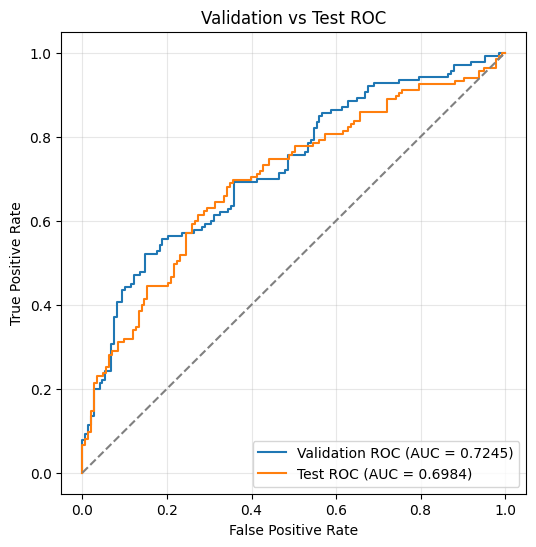

In [18]:
def collect_predictions(ds, model):
    y_true = []
    y_prob = []
    for xb, yb in ds:
        pb = model.predict(xb, verbose=0).reshape(-1)
        y_true.append(yb.numpy().reshape(-1))
        y_prob.append(pb)
    return np.concatenate(y_true).astype("int32"), np.concatenate(y_prob)

val_true, val_prob = collect_predictions(val_ds_prep, best_model)
test_true, test_prob = collect_predictions(test_ds_prep, best_model)
test_pred = (test_prob >= 0.5).astype("int32")

print("Positive class for ROC/AUC:", class_names[1])
print("First 20 val_true:", val_true[:20])
print("First 20 val_prob:", np.round(val_prob[:20], 4))
print("First 20 test_true:", test_true[:20])
print("First 20 test_prob:", np.round(test_prob[:20], 4))
print("Validation probability range:", float(val_prob.min()), float(val_prob.max()))
print("Validation probability mean/std:", float(val_prob.mean()), float(val_prob.std()))
print("Test probability range:", float(test_prob.min()), float(test_prob.max()))
print("Test probability mean/std:", float(test_prob.mean()), float(test_prob.std()))

val_fpr, val_tpr, _ = roc_curve(val_true, val_prob)
test_fpr, test_tpr, _ = roc_curve(test_true, test_prob)
val_auc = roc_auc_score(val_true, val_prob)
test_auc = roc_auc_score(test_true, test_prob)
test_acc = accuracy_score(test_true, test_pred)
cm = confusion_matrix(test_true, test_pred)

print(f"Validation AUC: {val_auc:.4f}")
print(f"Test AUC: {test_auc:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")
print("Confusion Matrix:\n", cm)
print("Classification Report:\n", classification_report(test_true, test_pred, target_names=class_names))
if test_auc < 0.55:
    print("AUC is below 0.55. Stop tuning ViT further and run the ResNet50 baseline with the same split.")

plt.figure(figsize=(6, 6))
plt.plot(val_fpr, val_tpr, label=f"Validation ROC (AUC = {val_auc:.4f})")
plt.plot(test_fpr, test_tpr, label=f"Test ROC (AUC = {test_auc:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Validation vs Test ROC")
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()


In [19]:
import csv
import json
from pathlib import Path
from sklearn.metrics import precision_score, recall_score, f1_score

results_dir = Path("results")
results_dir.mkdir(exist_ok=True)

model_name = "vit"


def save_predictions_csv(y_true, y_prob, split):
    path = results_dir / f"{model_name}_{split}_predictions.csv"
    with path.open("w", newline="", encoding="utf-8") as f:
        writer = csv.writer(f)
        writer.writerow(["y_true", "y_prob"])
        for yt, yp in zip(y_true, y_prob):
            writer.writerow([int(yt), float(yp)])
    print("Saved:", path)


metrics_summary = {
    "model": model_name,
    "validation_auc": float(val_auc),
    "test_auc": float(test_auc),
    "test_accuracy": float(test_acc),
    "test_precision": float(precision_score(test_true, test_pred)),
    "test_recall": float(recall_score(test_true, test_pred)),
    "test_f1": float(f1_score(test_true, test_pred)),
}

save_predictions_csv(val_true, val_prob, "val")
save_predictions_csv(test_true, test_prob, "test")

metrics_path = results_dir / f"{model_name}_metrics.json"
metrics_path.write_text(json.dumps(metrics_summary, indent=2), encoding="utf-8")
print("Saved:", metrics_path)
print(metrics_summary)


Saved: results/vit_val_predictions.csv
Saved: results/vit_test_predictions.csv
Saved: results/vit_metrics.json
{'model': 'vit', 'validation_auc': 0.7244691119691119, 'test_auc': 0.6983682983682984, 'test_accuracy': 0.6654676258992805, 'test_precision': 0.647887323943662, 'test_recall': 0.6814814814814815, 'test_f1': 0.6642599277978339}


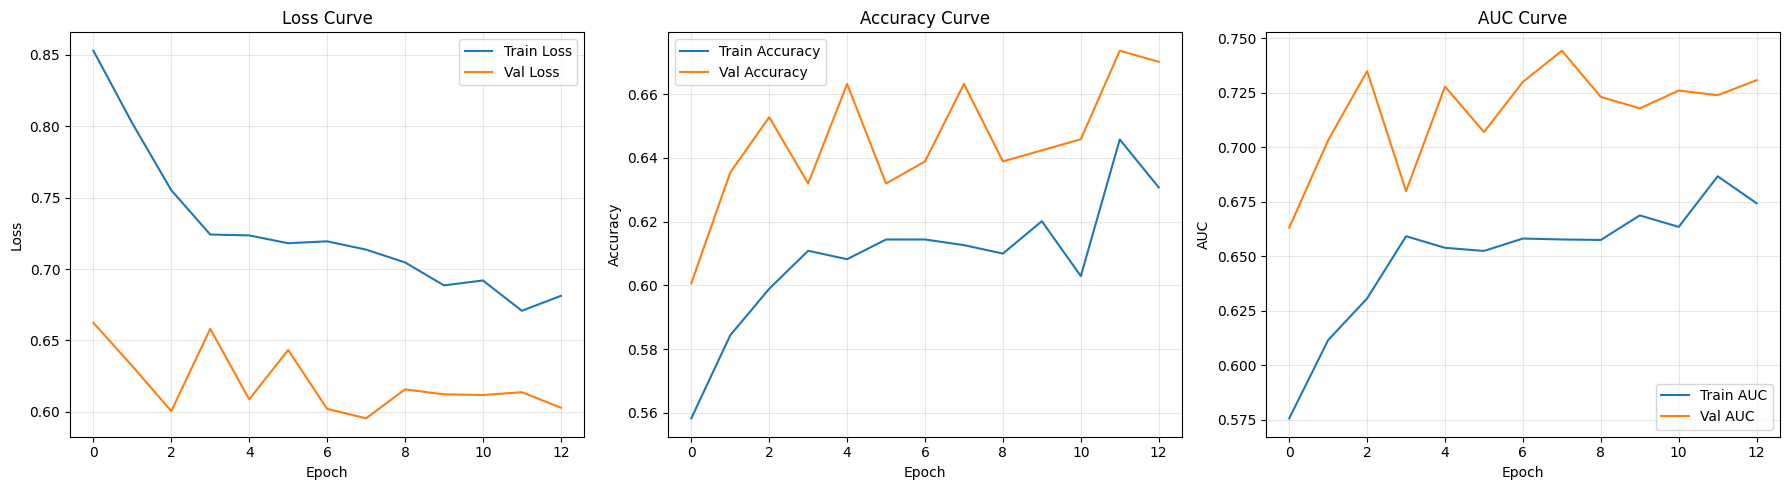

In [20]:
def merge_history(*histories):
    merged = {}
    for h in histories:
        if h is None:
            continue
        for k, v in h.history.items():
            merged.setdefault(k, []).extend(v)
    return merged

all_history = merge_history(history1, history2)

plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
plt.plot(all_history["loss"], label="Train Loss")
plt.plot(all_history["val_loss"], label="Val Loss")
plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 2)
plt.plot(all_history["acc"], label="Train Accuracy")
plt.plot(all_history["val_acc"], label="Val Accuracy")
plt.title("Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 3)
plt.plot(all_history["auc"], label="Train AUC")
plt.plot(all_history["val_auc"], label="Val AUC")
plt.title("AUC Curve")
plt.xlabel("Epoch")
plt.ylabel("AUC")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
